# MUSIN-G Dataset Loader Demo

This notebook demonstrates how to use the BCMIMusingLoader to load the MUSIN-G dataset,
which contains EEG recordings from 20 subjects listening to 12 different songs.

## Dataset Overview
- **Subjects**: 20
- **Songs**: 12 (various genres)
- **Sessions**: 12 per subject (one per song)
- **Sampling Rate**: 250 Hz
- **Format**: BIDS-compliant EEGLAB .set files
- **Music IDs**: Integer from 0 to 11 (MusingMusicId)

In [2]:
from pathlib import Path
import sys

# Add parent directory to path if needed
project_root = Path.cwd()
# if str(project_root) not in sys.path:
#     sys.path.insert(0, str(project_root))

from eeg_music.bcmi import BCMIMusingLoader, create_bcmi_loader
from eeg_music.data import MusingMusicId, MusicFilename, copy_from_dataloader_into_dir
from eeg_music.data import EEGMusicDataset

## 1. Load MUSIN-G Dataset with BCMIMusingLoader

We can use either the specific loader class or the factory function.

In [3]:
# Path to the musin-g dataset
musin_g_path = Path(".") / "datasets" / "musin_g_data"

# Method 1: Direct instantiation
loader = BCMIMusingLoader(str(musin_g_path))

# Method 2: Using factory function (automatically detects dataset type)
# loader = create_bcmi_loader(str(musin_g_path))

print(f"Dataset: {loader.dataset_name}")
print(f"Number of subjects: {len(loader.subjects)}")
print(f"Subjects: {loader.subjects[:5]}...")  # Show first 5

Dataset: musin-g
Number of subjects: 20
Subjects: ['001', '002', '003', '004', '005']...


In [4]:
# loader_export = BCMIMusingLoader(str(musin_g_path))
# loader_export.load_all_subjects()
new_dataset_save_dir = Path("./datasets/musin_g_export2")
# copy_from_dataloader_into_dir(loader_export, new_dataset_save_dir)

ds = EEGMusicDataset.load_ondisk(new_dataset_save_dir)

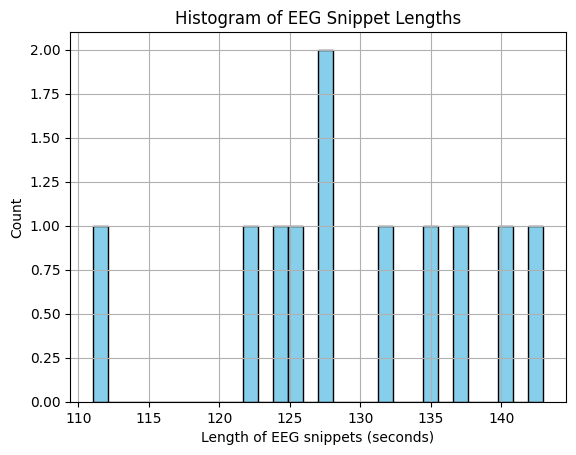

In [18]:
import matplotlib.pyplot as plt

s = set()
for t in ds:
  l = t.eeg_data.get_eeg().length_seconds()
  s.add(l)

plt.hist(list(s), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Length of EEG snippets (seconds)')
plt.ylabel('Count')
plt.title('Histogram of EEG Snippet Lengths')
plt.grid(True)
plt.show()


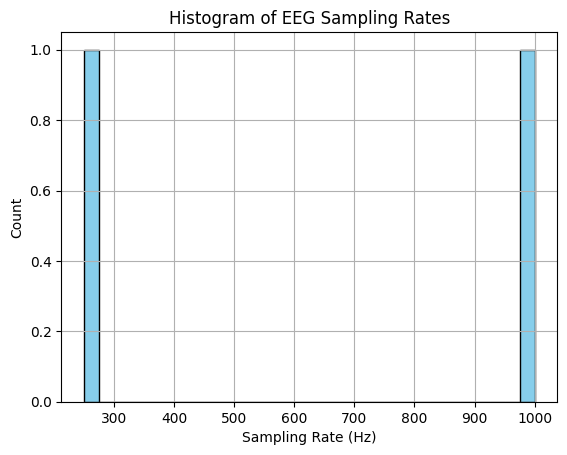

In [13]:
import matplotlib.pyplot as plt

s = set()
for t in ds:
  sr = t.eeg_data.get_eeg().raw_eeg.info['sfreq']
  s.add(sr)

plt.hist(list(s), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Sampling Rate (Hz)')
plt.ylabel('Count')
plt.title('Histogram of EEG Sampling Rates')
plt.grid(True)
plt.show()


In [6]:
ds[0].eeg_data.get_eeg().raw_eeg.ch_names

['E1',
 'E2',
 'E3',
 'E4',
 'E5',
 'E6',
 'E7',
 'E8',
 'E9',
 'E10',
 'E11',
 'E12',
 'E13',
 'E14',
 'E15',
 'E16',
 'E17',
 'E18',
 'E19',
 'E20',
 'E21',
 'E22',
 'E23',
 'E24',
 'E25',
 'E26',
 'E27',
 'E28',
 'E29',
 'E30',
 'E31',
 'E32',
 'E33',
 'E34',
 'E35',
 'E36',
 'E37',
 'E38',
 'E39',
 'E40',
 'E41',
 'E42',
 'E43',
 'E44',
 'E45',
 'E46',
 'E47',
 'E48',
 'E49',
 'E50',
 'E51',
 'E52',
 'E53',
 'E54',
 'E55',
 'E56',
 'E57',
 'E58',
 'E59',
 'E60',
 'E61',
 'E62',
 'E63',
 'E64',
 'E65',
 'E66',
 'E67',
 'E68',
 'E69',
 'E70',
 'E71',
 'E72',
 'E73',
 'E74',
 'E75',
 'E76',
 'E77',
 'E78',
 'E79',
 'E80',
 'E81',
 'E82',
 'E83',
 'E84',
 'E85',
 'E86',
 'E87',
 'E88',
 'E89',
 'E90',
 'E91',
 'E92',
 'E93',
 'E94',
 'E95',
 'E96',
 'E97',
 'E98',
 'E99',
 'E100',
 'E101',
 'E102',
 'E103',
 'E104',
 'E105',
 'E106',
 'E107',
 'E108',
 'E109',
 'E110',
 'E111',
 'E112',
 'E113',
 'E114',
 'E115',
 'E116',
 'E117',
 'E118',
 'E119',
 'E120',
 'E121',
 'E122',
 'E123',
 

In [7]:
from eeg_music.data import MappedDataset
from eeg_music.onset_conversion import trial_wavraw_to_noteonsets
from eeg_music.eegpt import USING_CHANNELS
from eeg_music.data import prepare_trial
from eeg_music.data import rereference_trial

# some_channels = ["F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6", "T7", "C3", "Cz", "C4", "T8", "CP5", "CP6", "P7", "P8"]
# less_some_channels = ["F7", "Fz", "FC1", "FC6", "T7", "Cz", "CP5", "P8"]
# minimal_channels = ["Fz", "T7", "Cz", "T8"]

less_some_channels = ["E11" , "E18", "E19", "E33", "E45", "E47", "E96", "E116"]

mapped = MappedDataset(ds, lambda x: 
  rereference_trial(
      prepare_trial(
        x,
        eeg_resample=250,
        eeg_l_freq=0.5,
        eeg_h_freq=30.0,
        pick_channels=less_some_channels, # 8 channels
      ) # type: ignore
    )  
)

print(mapped[0])

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)

Sampling frequency of the instance is already 250.0, returning unmodified.
TrialData(
  dataset=musin-g, subject=001, session=01, run=1, trial_id=song_01,
  music_filename=song_01.wav,
  eeg=RawEeg(sfreq=250, chans=8, secs=136.996, samples=34249),
  music=MusingMusicIdData
)


In [10]:
mapped[2].eeg_data.get_eeg().raw_eeg.get_data().shape

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)

Sampling frequency of the instance is already 250.0, returning unmodified.


(8, 35749)

In [ ]:
mapped.save(Path("./datasets/musing_preprocessed/musing_8ch"))

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)

Sampling frequency of the instance is already 250.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transitio

/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/data.py:493: RuntimeWarning: EDF format requires equal-length data blocks, so 0.004 seconds of edge values were appended to all channels when writing the final block.
  mne.export.export_raw(filepath, self.raw_eeg, fmt="edf", overwrite=True)


Sampling frequency of the instance is already 250.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)



/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/data.py:493: RuntimeWarning: EDF format requires equal-length data blocks, so 0.004 seconds of edge values were appended to all channels when writing the final block.
  mne.export.export_raw(filepath, self.raw_eeg, fmt="edf", overwrite=True)


Sampling frequency of the instance is already 250.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)

Sampling frequency of the instance is already 250.0, returning unmodified.


...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 6601 samples (6.601 s)



/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/data.py:493: RuntimeWarning: EDF format requires equal-length data blocks, so 0.004 seconds of edge values were appended to all channels when writing the final block.
  mne.export.export_raw(filepath, self.raw_eeg, fmt="edf", overwrite=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 6601 samples (6.601 s)



/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/data.py:493: RuntimeWarning: EDF format requires equal-length data blocks, so 0.004 seconds of edge values were appended to all channels when writing the final block.
  mne.export.export_raw(filepath, self.raw_eeg, fmt="edf", overwrite=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 6601 samples (6.601 s)



In [ ]:
import matplotlib.pyplot as plt

s = set()
ll = set()
for t in mapped:
  sr = t.eeg_data.get_eeg().raw_eeg.info['sfreq']
  l = t.eeg_data.get_eeg().length_seconds()
  ch = t.eeg_data.get_eeg().raw_eeg.get_data().shape[1]
  s.add(sr)
  ll.add(l)

plt.hist(list(s), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Sampling Rate (Hz)')
plt.ylabel('Count')
plt.title('Histogram of EEG Sampling Rates')
plt.grid(True)
plt.show()

plt.hist(list(ll), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Length (s)')
plt.ylabel('Count')
plt.title('Histogram of EEG Lengths')
plt.grid(True)
plt.show()


## 7. Load Exported Dataset with EegMusicDataset

After exporting, we can load the dataset using EegMusicDataset.

In [ ]:
# Assuming you've exported the dataset in step 6
# exported_path = output_dir

# Load with EegMusicDataset
# dataset = EegMusicDataset(base_dir=exported_path)
# print(f"Loaded {len(dataset)} trials")

# Access a trial
# trial = dataset[0]
# print(f"\nFirst trial:")
# print(trial.pretty())

## 8. Access Behavioral Data

The MUSIN-G dataset includes behavioral ratings (enjoyment and familiarity) in the stimuli directory.

In [ ]:
import pandas as pd

# Load behavioral data
behavioral_file = musin_g_path / "stimuli" / "Behavioural_data"
behavioral_df = pd.read_csv(behavioral_file, sep="\t")

print("Behavioral data columns:", behavioral_df.columns.tolist())
print(f"\nShape: {behavioral_df.shape}")
print("\nFirst few rows:")
print(behavioral_df.head(10))

# Get ratings for subject 1, song 1
subject_1_song_1 = behavioral_df[(behavioral_df['Subject'] == 1) & (behavioral_df['Song_ID'] == 1)]
if not subject_1_song_1.empty:
    enjoyment = subject_1_song_1['Enjoyment'].iloc[0]
    familiarity = subject_1_song_1['Familiarity'].iloc[0]
    print(f"\nSubject 1, Song 1:")
    print(f"  Enjoyment: {enjoyment}/5")
    print(f"  Familiarity: {familiarity}/5")

## 9. Song Information

The musing.py module contains detailed information about all 12 songs.

In [ ]:
from eeg_music.musing import songs_info_enhanced

print("\nSong Information:")
print("=" * 80)
for song_id, info in songs_info_enhanced.items():
    print(f"\nSong {song_id}: {info['name']}")
    print(f"  Artist: {info['artist']}")
    print(f"  Genre: {info['genre']}")
    print(f"  Duration: {info['duration']}s")
    print(f"  Tempo: {info['tempo']} BPM" if info['tempo'] else "  Tempo: N/A")
    print(f"  Characteristics: {info['characteristics']}")

## Summary

This notebook demonstrated:

1. **Loading MUSIN-G dataset** with `BCMIMusingLoader`
2. **Understanding `MusingMusicId`** type (integers 1-12 for 12 songs)
3. **Accessing EEG data** for subjects and sessions
4. **Iterating over trials** with `trial_iterator()`
5. **Exporting dataset** with `copy_from_dataloader_into_dir()`
6. **Loading exported data** with `EegMusicDataset`
7. **Accessing behavioral ratings** (enjoyment and familiarity)
8. **Song metadata** from the musing module

### Key Features of MUSIN-G Loader:

- **Compatible with BCMI framework**: Extends `BaseBCMILoader`
- **BIDS format support**: Uses mne_bids for loading
- **Session-based organization**: Each of 12 sessions represents one song
- **Full song trials**: Each trial contains the complete EEG recording for one song
- **No audio files**: The dataset contains only EEG data and metadata
- **Behavioral data**: Ratings available separately in stimuli directory